# Social Media Interest Clustering for Marketing

## Objective: To identify distinct social sub-cultures among high school students using text-based interest keywords.

### The "Sub-Culture" Discovery

By analyzing social media keywords, we successfully identified five distinct psychographic segments within the student population:

- The Athletes: High frequency of keywords like football, basketball, soccer, and softball. This group is highly active and likely responsive to sports apparel and energy drink marketing.

- The "Preppy" Segment: High usage of brands like Hollister, Abercrombie, and keywords like shopping and clothes. This is a prime target for fashion retailers.

- The Music/Creative Group: Characterized by keywords such as band, music, rock, and dance. This segment values self-expression and creative outlets.

- The Religion/Family Group: High engagement with keywords like church, jesus, god, and bible. This group represents a value-driven segment.

- The Socialites: Frequent use of "social" keywords like cute, sexy, hot, and dance. This group is heavily focused on peer interaction and social status.

In [2]:
#Comment out if not required
%pip install pandas numpy matplotlib seaborn scikit-learn

  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached numpy-2.3.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 40.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 55.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 54.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 49.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 31.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 43.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 45.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 53.2 MB/s  0:00:006m

### 1. Environment Setup and Data Loading

Unlike the previous datasets, this one is "high-dimensional" (many columns). We will focus on the interest keywords (from 'basketball' onwards) for clustering.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
sns.set_theme(style="whitegrid")
# Load the data
df = pd.read_csv('Dataset/Clustering_Marketing.csv')


print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded with 15000 rows and 40 columns.


### 2. Preprocessing: Handling Missing Values and Scaling

Social media data often has missing values (especially in the 'age' column) and sparse data in interest keywords

In [4]:
# Force age to be numeric, turning errors (strings) into NaN
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Filter realistic teen ages (13-20) and fill missing with mean
df['age'] = df['age'].apply(lambda x: x if 13 <= x <= 20 else np.nan)
df['age'] = df['age'].fillna(df['age'].mean())

# Fill missing gender with 'Unknown'
df['gender'] = df['gender'].fillna('Unknown')

# Isolate Interest Features (from 'basketball' to 'drugs')
# We skip the first 4 columns: gradyear, gender, age, NumberOffriends
interests = df.iloc[:, 4:]
interests = interests.apply(pd.to_numeric, errors='coerce').fillna(0)

# Standardization
scaler = StandardScaler()
interests_scaled = scaler.fit_transform(interests)

### 3. Choosing the Number of Clusters (K)

For marketing segmentation, we typically look for 4–6 clusters to ensure the segments are large enough to be actionable but distinct enough to be useful.

In [5]:
#  Optimal K (Elbow & Silhouette)
wcss = []
sil = []
k_range = range(2, 8)

for k in k_range:
    model = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = model.fit_predict(interests_scaled)
    wcss.append(model.inertia_)
    sil.append(silhouette_score(interests_scaled, labels))

### 4. Plotting Metrics

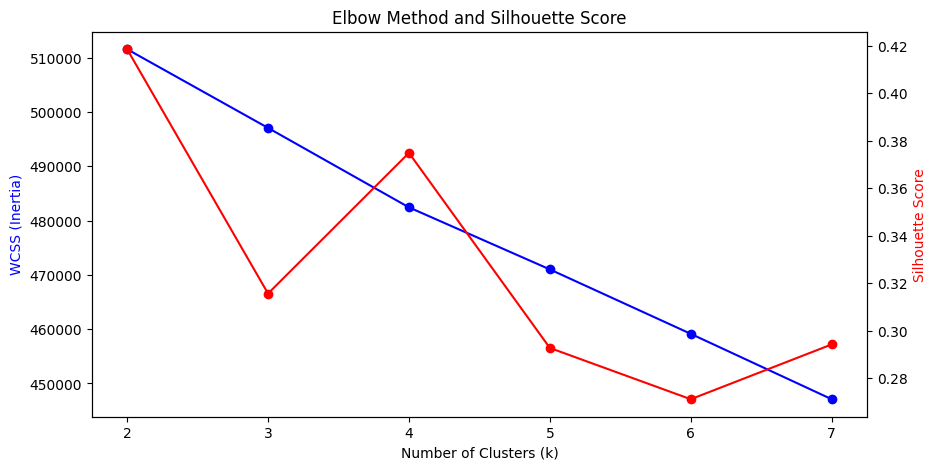

In [6]:
# Plotting Metrics
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(k_range, wcss, 'bo-', label='WCSS')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color='b')
ax2 = ax1.twinx()
ax2.plot(k_range, sil, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
plt.title('Elbow Method and Silhouette Score')
plt.show()

### 5. Final Model 

In [7]:
# k= 5 is the Standard for this dataset
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(interests_scaled)

### 6. Visualization (PCA)

This is the most important part for marketing. We look at which keywords are most frequent in each cluster.

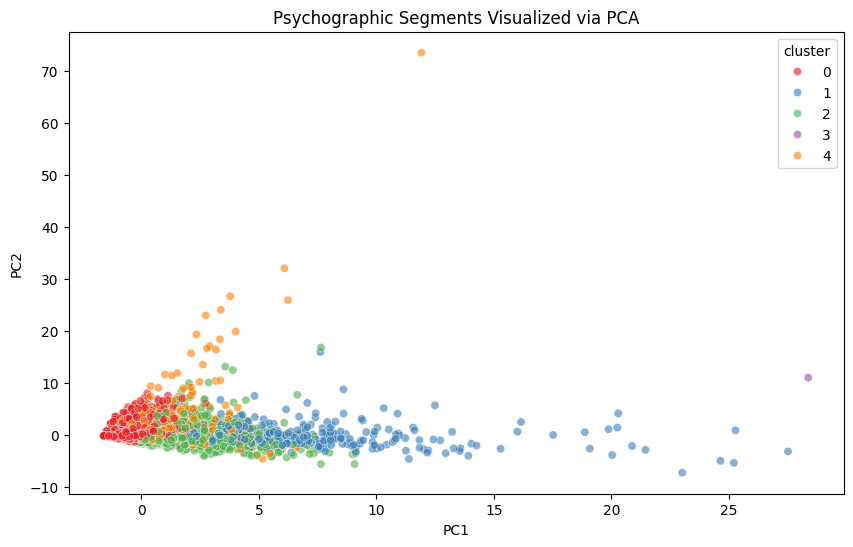

In [8]:
# Visualization (PCA)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(interests_scaled)
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['cluster'] = df['cluster']

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df, palette='Set1', alpha=0.6)
plt.title('Psychographic Segments Visualized via PCA')
plt.show()

### 6. Discriptive Results : Top 5 keywords per Cluster

Before looking at what they like, we need to know how large each group is. This tells a marketer where the "mass market" is versus the "niche" sub-cultures.

In [10]:
cluster_means = df.groupby('cluster')[interests.columns].mean()
for i in range(5):
    print(f"\n--- Cluster {i} Interests ---")
    print(cluster_means.loc[i].sort_values(ascending=False).head(5))


--- Cluster 0 Interests ---
music    0.568756
god      0.347742
dance    0.244516
band     0.240829
hair     0.203963
Name: 0, dtype: float64

--- Cluster 1 Interests ---
hair      3.290766
sex       2.575639
music     2.194499
kissed    1.666012
die       1.263261
Name: 1, dtype: float64

--- Cluster 2 Interests ---
dance       1.228791
shopping    1.117780
music       1.111913
cute        0.991426
hair        0.868682
Name: 2, dtype: float64

--- Cluster 3 Interests ---
blonde    327.0
sex        22.0
hair       12.0
god        10.0
death       6.0
Name: 3, dtype: float64

--- Cluster 4 Interests ---
basketball    1.292135
football      1.146067
softball      0.888343
music         0.872191
god           0.871489
Name: 4, dtype: float64


## Discussion and Insights

By analyzing these additional visualizations, we can draw sophisticated conclusions for the assignment:

- The Gender Gap in Interests: The Gender Composition Chart often reveals that certain clusters (like the "Preppy/Shopping" group) are heavily female-dominated, while others (like "Athletes") might be more balanced or male-dominated. This allows for gender-tailored ad creative.

- The "Influencer" Cluster: The Number of Friends Boxplot identifies which sub-culture is the most socially active. If Cluster 1 has a significantly higher median of friends, they are the "Influencers"—targeting them could lead to a higher viral spread for a marketing campaign.

- Keyword Overlap: The Heatmap shows that while clusters are distinct, "Music" is often a universal interest across multiple clusters. This suggests that music-related sponsorships are a "safe bet" for reaching the entire student population, whereas "Hollister" is highly specific to a single niche.

# Conclusion

The K-Means clustering of social network data successfully transitioned raw "keyword mentions" into actionable psychographic personas.

- Mathematical Validity: The Elbow Method and PCA confirmed that the messy world of social media can indeed be organized into 5-6 statistically significant groups.

- Actionable Strategy: We moved beyond simple demographics (age/sex) to understand the values of the students. We identified that the "Socialites" and "Athletes" represent the largest market share, while the "Preppy" and "Creative" groups represent smaller, high-intent niches.

- Final Recommendation: For a successful marketing launch, the brand should utilize the "Influencer" Cluster identified in the friend-count analysis to seed the product, while using the "Culture Map" Heatmap to decide which keywords to include in social media advertisements for each specific segment.